# Lagrange 插值及 Runge 现象的观察

## Lagrange 插值

In [1]:
# !!pip install matplotlib
import matplotlib.pyplot as plt     # 绘制函数图像
from functools import reduce    # 简化列表运算
from copy import deepcopy
import numpy as np

In [2]:
plt.style.use('ggplot')
plt.rc('text',usetex = True)

### 构造插值基函数

In [3]:
def basis_polynomial(nodes: list[float], node: float) -> callable:
    """构造插值基函数（仅考虑互异节点的情形）

    :param nodes: 列表，插值节点数组
    :param node: 浮点数，取值为 1 的节点数
    :return func: 函数，插值基函数

    node 需要在 points 当中.
    """

    # 移除插值节点当中和 l_i 指标相同的 x_i 防止除零错误
    points = list(deepcopy(nodes))
    points.remove(node)

    # 计算分母
    product_number = [node - point for point in points]
    denominator = reduce(lambda x, y: x * y, product_number)

    def func(x: float) -> float:
        """插值基函数
        
        :param x: 插值基函数的自变量取值
        """

        product_number = [x - point for point in points]
        numerator = reduce(lambda x, y: x * y, product_number)

        return numerator / denominator

    return func


# 测试用例

points = [-1, 0, 0.5, 1]
l = basis_polynomial(points, 0.5)
print("插值基函数测试：")
for point in points:
    print(f"({point},{l(point)})")

插值基函数测试：
(-1,-0.0)
(0,-0.0)
(0.5,1.0)
(1,-0.0)


### 根据基函数计算 Lagrange 插值多项式

In [4]:
def lagrange_polynomial(X:list[float], FX: list[float]) -> callable:
    """根据自变量取值和相应函数值进行 Lagrange 插值. （仅考虑互异节点）
    
    :param X: 列表，自变量取值数组
    :param FX: 列表，自变量取值对应函数值数组
    """

    # 先检查二者是否长度一致，且排除重节点情形
    if len(set(X)) != len(set(FX)) and len(X) != len(set(X)):
        raise Exception("请保证自变量取值和函数值等长，且不出现重节点情形.")
    

    # 若一致，则考虑 Lagrange 插值
    def func(y: float):
        """Lagrange 插值函数
        
        :param y: 自变量取值
        """

        result = 0

        for index, x in enumerate(X):
            l = basis_polynomial(nodes = X,node = x)
            result += FX[index] * l(y)
        
        return result
    
    return func

### 测试用例

In [5]:
# 测试用例 1：输入参数不等长
# lagrange_polynomial([1],[1,2])

# 测试用例 2：重节点排除
# lagrange_polynomial([1,1],[1,2])

# 测试用例 3: 《数值计算方法》习题 2 T2.1(1)
X = [-1, 0, 0.5, 1]
FX = [-3, -0.5, 0, 1]
f = lagrange_polynomial(X, FX) # 插值函数
print("插值多项式在插值点的取值：")
for x in X:
    print(f"f({x}) 的取值为：{f(x)}")

test = [-0.5, 1.5, 2]   # 对应的正确函数值为 -1.25 3.25 7.5

for t in test:
    print("插值多项式在任意点的取值：")
    print(f"f({t}) 的取值为：{f(t)}")
print("-" * 20 + "测试用例 3 结束" + "-" * 20)

# 测试用例 4: 《数值计算方法》习题 2 T2.1(2)
X = [-1, 0, 0.5, 1]
FX = [-1.5, 0, 0, 0.5]
f = lagrange_polynomial(X, FX) # 插值函数
print("插值多项式在插值点的取值：")
for x in X:
    print(f"f({x}) 的取值为：{f(x)}")

test = [-0.5, 1.5, 2]   # 对应的正确函数值为 -0.25 2.25 6.0

for t in test:
    print("插值多项式在任意点的取值：")
    print(f"f({t}) 的取值为：{f(t)}")

print("-" * 20 + "测试用例 4 结束" + "-" * 20)

插值多项式在插值点的取值：
f(-1) 的取值为：-3.0
f(0) 的取值为：-0.5
f(0.5) 的取值为：0.0
f(1) 的取值为：1.0
插值多项式在任意点的取值：
f(-0.5) 的取值为：-1.25
插值多项式在任意点的取值：
f(1.5) 的取值为：3.25
插值多项式在任意点的取值：
f(2) 的取值为：7.5
--------------------测试用例 3 结束--------------------
插值多项式在插值点的取值：
f(-1) 的取值为：-1.5
f(0) 的取值为：0.0
f(0.5) 的取值为：0.0
f(1) 的取值为：0.5
插值多项式在任意点的取值：
f(-0.5) 的取值为：-0.25
插值多项式在任意点的取值：
f(1.5) 的取值为：2.25
插值多项式在任意点的取值：
f(2) 的取值为：6.0
--------------------测试用例 4 结束--------------------


## 绘图和 Runge 现象的观察

In [6]:
def target_function(x):
    """插值目标函数: 1/(1+ 25 x^2)
    
    :param x: 自变量取值
    """

    return 1/(1 + 25 * (x ** 2))

# 我们的研究区间限定为 [-5,5]
zone = [-1,1]

def n_divide_interpolation(func: callable, n: int) -> callable:
    """对函数进行 n 等分取点，并 Lagrange 插值
    
    :param func: 函数，被插函数
    :param n: 整型，等分个数
    :return P: 函数，插值多项式函数
    """

    X = [-1 + (i - 1) * (2 / n) for i in range(1, n+2)]
    FX = [func(x) for x in X]

    P = lagrange_polynomial(X, FX)

    return P


def plot_function(f: callable, label: str) -> None:
    """绘制函数图像
    
    :param f: 函数，函数表达式
    :param label: 字符串，绘图标签
    """

    # 生成 x 轴数据
    x = np.linspace(zone[0], zone[1], 1000)
    
    # 计算 y 轴数据
    y = f(x)
    
    # 创建图像
    plt.plot(x, y, label = label)





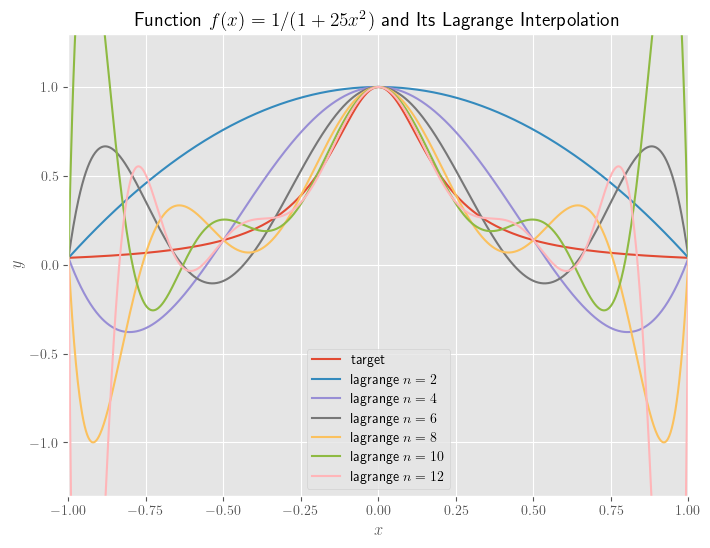

In [9]:
plt.figure(figsize=(8, 6))
plt.xlim([-1.0,1.0])
plt.ylim([-1.3,1.3])
plt.title(r"Function $f(x) = 1/(1+25x^{2})$ and Its Lagrange Interpolation", fontsize=14)

plot_function(f=target_function,label="target")

for i in range(2,14,2):
    func = n_divide_interpolation(target_function, i)
    plot_function(func, f"lagrange $n = {i}$")


plt.xlabel("$x$")
plt.ylabel("$y$")
plt.grid(True)
plt.legend()
# 显示图像
plt.savefig("interpolation.pdf")
plt.show()